In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import utils
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train_norm = x_train.reshape(60000, 784) / 255.0
x_test_norm = x_test.reshape(10000, 784) / 255.0

y_train_cat = utils.to_categorical(y_train, 10)
y_test_cat = utils.to_categorical(y_test, 10)
print("Бібліотеки та дані успішно завантажено!")

Бібліотеки та дані успішно завантажено!


In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(784,)))

    model.add(Dense(
        units=hp.Int('units_1', min_value=128, max_value=1024, step=32),
        activation='relu'
    ))

    model.add(Dense(
        units=hp.Int('units_2', min_value=128, max_value=1024, step=32),
        activation='relu'
    ))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='SGD',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
tuner_bo = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='tuner_results',
    project_name='lab3_part2_bayesian'
)

tuner_bo.search_space_summary()

Reloading Tuner from tuner_results/lab3_part2_bayesian/tuner0.json
Search space summary
Default search space size: 2
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}


In [ ]:
stop_early = EarlyStopping(monitor='val_accuracy', patience=3)

tuner_bo.search(
    x_train_norm,
    y_train_cat,
    batch_size=50,
    epochs=50,
    validation_split=0.2,
    callbacks=[stop_early],
    verbose=1
)


--- ТОП-3 НАЙКРАЩІ МОДЕЛІ (БАЄСІВСЬКА ОПТИМІЗАЦІЯ) ---
1 місце: Шар 1 = 800 нейронів | Шар 2 = 352 нейронів
    Точність на тестовій вибірці: 87.94%
2 місце: Шар 1 = 384 нейронів | Шар 2 = 864 нейронів
    Точність на тестовій вибірці: 87.73%
3 місце: Шар 1 = 864 нейронів | Шар 2 = 544 нейронів
    Точність на тестовій вибірці: 87.53%


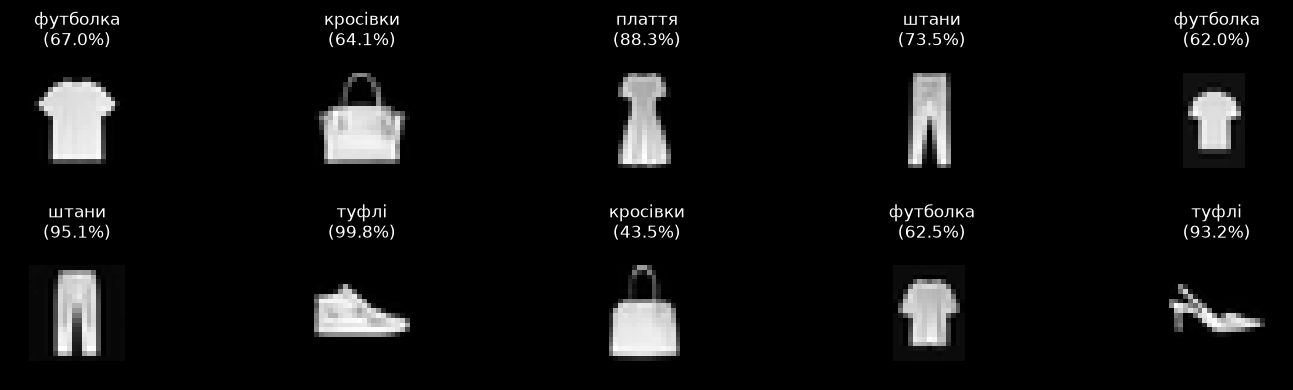

In [ ]:
best_models = tuner_bo.get_best_models(num_models=3)
best_hps = tuner_bo.get_best_hyperparameters(num_trials=3)

print("\n--- ТОП-3 НАЙКРАЩІ МОДЕЛІ (БАЄСІВСЬКА ОПТИМІЗАЦІЯ) ---")
for i, hp in enumerate(best_hps):
    model = best_models[i]
    loss, accuracy = model.evaluate(x_test_norm, y_test_cat, verbose=0)
    print(f"{i+1} місце: Шар 1 = {hp.get('units_1')} нейронів | Шар 2 = {hp.get('units_2')} нейронів")
    print(f"    Точність на тестовій вибірці: {accuracy * 100:.2f}%")

best_model = best_models[0]

classes = ['футболка', 'штани', 'светр', 'плаття', 'пальто',
           'туфлі', 'сорочка', 'кросівки', 'сумка', 'черевики']

def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')
    img_inverted = ImageOps.invert(img)
    bbox = img_inverted.getbbox()
    if bbox:
        img_inverted = img_inverted.crop(bbox)
    final_img = Image.new('L', (28, 28), color=0)
    img_inverted.thumbnail((20, 20), Image.Resampling.LANCZOS)
    offset_x = (28 - img_inverted.width) // 2
    offset_y = (28 - img_inverted.height) // 2
    final_img.paste(img_inverted, (offset_x, offset_y))
    img_array = np.array(final_img) / 255.0
    return img_array, img_array.reshape(1, 784)

images_folder = 'test_images'
image_files = [f for f in os.listdir(images_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]

plt.figure(figsize=(15, 2 * ((len(image_files) + 4) // 5)))
for i, file_name in enumerate(image_files):
    img_path = os.path.join(images_folder, file_name)
    img_plot, img_for_model = preprocess_image(img_path)

    prediction = best_model.predict(img_for_model, verbose=0)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    plt.subplot(((len(image_files) + 4) // 5), 5, i + 1)
    plt.imshow(img_plot, cmap='gray')
    plt.title(f"{classes[predicted_class]}\n({confidence:.1f}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()